## Проведем небольшой анализ данных перед обучением модели классификации

In [1]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import IncrementalPCA
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# тесты для проверки корреляций
from phik.report import plot_correlation_matrix
from phik import phik_matrix

# ⏳ прогресс-бары
import tqdm as tqdm_lib
from tqdm import tqdm

# 🧠 обработка текста и NLP
import spacy
try:
    import transformers
    from transformers import AutoModel, AutoTokenizer
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "transformers"], stdout=subprocess.DEVNULL)
    import transformers
    from transformers import AutoModel, AutoTokenizer


# 🤖 pyTorch
import torch



pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', 120)


/opt/anaconda3/envs/datasphere_cli_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# создаем функцию очистки текста
def _clean_single_text(text):
    return re.sub(r"[^\w\s]", " ", text.lower())

# создаем функцию предобработки текста
def preprocess_texts_optimized(texts, nlp_model_name,
                               batch_size_cpu=256,
                               num_processes_for_cleaning=-1,
                               num_processes_for_spacy_cpu=-1):
    
    print(f"🔍 Запуск предобработки для {len(texts)} текстов...")
    
    # предварительная очистка текстов
    cleaned_texts = [_clean_single_text(text) for text in tqdm(texts, desc="Очистка")]

    # spaCy и лемматизация
    nlp = None
    processed_lemmas = []
    
    # загрузка NLP модели
    print(f"🔍 Загрузка spaCy модели: '{nlp_model_name}'.")
    nlp = spacy.load(nlp_model_name)

    # используем n_process для параллелизации
    if num_processes_for_spacy_cpu == -1:
        cpu_count = os.cpu_count()
        num_processes_for_spacy_cpu = max(1, cpu_count - 1)
    
    print(f"🔍 Лемматизация будет выполнена в {num_processes_for_spacy_cpu} потоках.")
    
    for doc in tqdm(nlp.pipe(cleaned_texts, batch_size=batch_size_cpu, n_process=num_processes_for_spacy_cpu), total=len(cleaned_texts), desc="Лемматизация (CPU)"):
        lemmas = [token.lemma_ for token in doc]
        processed_lemmas.append(" ".join(lemmas))
    
    print(f"🔍 Предобработка завершена. Обработано {len(processed_lemmas)} текстов.")
    return processed_lemmas

# создаем функцию для получения усредненного эмбеддинга текста
def get_embeddings_batch(texts, tokenizer, model, device, batch_size=64):
    texts = list(texts)
    embeddings = []

    print(f"🔍 Начало генерации эмбеддингов для {len(texts)} текстов на устройстве '{device}'.")
    for i in tqdm(range(0, len(texts), batch_size), desc="Генерация эмбеддингов"):
        batch_texts = texts[i:i+batch_size]

        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        )

        # Переносим каждый тензор на устройство
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        # берем attention mask (1 — реальные токены, 0 — паддинг)
        mask = inputs["attention_mask"].unsqueeze(-1).expand(outputs.last_hidden_state.size())
        masked_embeddings = outputs.last_hidden_state * mask

        # считаем среднее только по непаддинговым токенам
        summed = masked_embeddings.sum(dim=1)
        counts = mask.sum(dim=1)
        mean_pooled = summed / counts

        embeddings.extend(mean_pooled.cpu().numpy())
        
    print(f"🔍 Генерация эмбеддингов завершена")
    
    return embeddings


In [3]:
data = pd.read_parquet("../uc_data_labeling/data_download_09102025_uc.parquet")


In [4]:
data.head(2)

,id,account_id,contractor_id,date,payments_amount,purpose,article_id,expenditure,project_id,counterpartie_id,donor_id,robot_id,donor_cat_id,accounts__id,accounts__user_id,articles__id,articles__user_id,articles__parent_id,articles__name,projects__id,projects__user_id,projects__parent_id,projects__name,counterparties__id,counterparties__user_id,counterparties__parent_id,counterparties__name,robots__id,robots__user_id,article_alternative_names__user_id,universal_category
0,289,1,70,2022-09-08,1.0,None,0,incoming,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None
1,290,1,71,2022-09-08,1.0,None,0,incoming,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None


In [5]:
data.id.count()

641679

In [6]:
# отбираем строки где нет пропусков в целевом признаке 
data.dropna(subset=['universal_category'], inplace=True)

data.id.count()

576795

In [7]:
data = data.drop(
            [
                "robot_id",
                "accounts__id",
                "articles__id",
                "articles__user_id",
                "projects__id",
                "projects__user_id",
                "counterparties__id",
                "counterparties__user_id",
                "robots__user_id",
                "article_alternative_names__user_id",
            ],
            axis=1,
        )

# поправим типы данных и заполним пропуски метками missing (для текстовых значений категорий) и 0 для пропущенных ID
data[
    [
        "articles__parent_id",
        "projects__parent_id",
        "counterparties__parent_id",
        "robots__id",
    ]
] = (
    data[
        [
            "articles__parent_id",
            "projects__parent_id",
            "counterparties__parent_id",
            "robots__id",
        ]
    ]
    .fillna(0)
    .astype("int64")
)

data["purpose"] = data["purpose"].fillna("missing")
data["articles__name"] = data["articles__name"].fillna("missing")
data["projects__name"] = data["projects__name"].fillna("missing")
data["counterparties__name"] = data["counterparties__name"].fillna("missing")

# конвертируем дату в datetime
data["date"] = pd.to_datetime(data["date"], yearfirst=True, errors='coerce')

# и убираем записи из будущего и меньше нуля (и такое бывает)
yesterday = pd.Timestamp.today().normalize() - pd.Timedelta(days=1)
data = data[data["date"] <= yesterday]
#data = data[data["payments_amount"] > 0]

# переименуем и поправим тип столбца с фондами
data = data.rename(columns={"accounts__user_id": "user_id"})
data["user_id"] = data["user_id"].fillna(0).astype("int64")

In [8]:
# загрузим датасет с эмбеддингами, если его нет, то закодируем текстовое поле
path1 = 'data_w_emb_server_old.parquet'

if os.path.exists(path1):
        data_prepared = pd.read_parquet(path1)
else:
     
    # сначала очищаем и лемматизируем тексты
    data["clean_purpose"] = preprocess_texts_optimized(texts=data["purpose"],nlp_model_name="ru_core_news_sm")

    # грузим модели 
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")
    model = AutoModel.from_pretrained("DeepPavlov/rubert-base-cased")
    model = model.to(device)

    # и запускаем генерацию эмбеддингов в назначении платежа
    data["purpose_emb"] = get_embeddings_batch(data["clean_purpose"], tokenizer, model, device)

    # 1. усредняем эмбеддинг в одно число
    data["purpose_mean"] = data["purpose_emb"].apply(lambda x: float(np.mean(x)))

    # 2. выделяем три главные компоненты с предварительным масштабированием и по батчам  
    batch_size = 10_000
    scaler = StandardScaler()
    ipca = IncrementalPCA(n_components=3)

    # обучаем скейлер
    for i in tqdm(range(0, len(data), batch_size), desc="Обучение StandardScaler"):
        batch = np.vstack(data["purpose_emb"].iloc[i:i+batch_size])
        scaler.partial_fit(batch)

    # обучаем PCA на масштабированных данных
    for i in tqdm(range(0, len(data), batch_size), desc="Обучение IncrementalPCA"):
        batch = np.vstack(data["purpose_emb"].iloc[i:i+batch_size])
        batch_scaled = scaler.transform(batch)
        ipca.partial_fit(batch_scaled)

    # применяем трансформацию ко всему массиву
    transformed_batches = []
    for i in tqdm(range(0, len(data), batch_size), desc="Масштабируем эмбеддинги"):
        batch = np.vstack(data["purpose_emb"].iloc[i:i+batch_size]).astype(np.float32)
        batch_scaled = scaler.transform(batch)
        transformed_batches.append(ipca.transform(batch_scaled))
        
    purpose_pca_features = np.vstack(transformed_batches)

    # делаем датафрейм
    pca_column_names = [f"purpose_pca_{i+1}" for i in range(3)]
    data[pca_column_names] = purpose_pca_features

    # удалим ненужные столбцы
    data.drop(columns=["purpose", "clean_purpose", "purpose_emb"], inplace=True)

    # генерируем эмбеддинги для названий статей
    # сначала очищаем и лемматизируем тексты
    data["clean_articles__name"] = preprocess_texts_optimized(texts=data["articles__name"],nlp_model_name="ru_core_news_sm")
     # и запускаем генерацию эмбеддингов в названии статей
    data["articles__name_emb"] = get_embeddings_batch(data["clean_articles__name"], tokenizer, model, device)
    # усредняем эмбеддинг в одно число
    data["articles__name_mean"] = data["articles__name_emb"].apply(lambda x: float(np.mean(x)))
    # удалим ненужные столбцы
    data.drop(columns=["articles__name", "clean_articles__name", "articles__name_emb"], inplace=True)

    # генерируем эмбеддинги для названий проектов
    # сначала очищаем и лемматизируем тексты
    data["clean_projects__name"] = preprocess_texts_optimized(texts=data["projects__name"],nlp_model_name="ru_core_news_sm")
     # и запускаем генерацию эмбеддингов в названии статей
    data["projects__name_emb"] = get_embeddings_batch(data["clean_projects__name"], tokenizer, model, device)
    # усредняем эмбеддинг в одно число
    data["projects__name_mean"] = data["projects__name_emb"].apply(lambda x: float(np.mean(x)))
    # удалим ненужные столбцы
    data.drop(columns=["projects__name", "clean_projects__name", "projects__name_emb"], inplace=True)
    
    # генерируем эмбеддинги для названий доноров
    # сначала очищаем и лемматизируем тексты
    data["clean_counterparties__name"] = preprocess_texts_optimized(texts=data["counterparties__name"],nlp_model_name="ru_core_news_sm")
     # и запускаем генерацию эмбеддингов в названии статей
    data["counterparties__name_emb"] = get_embeddings_batch(data["clean_counterparties__name"], tokenizer, model, device)
    # усредняем эмбеддинг в одно число
    data["counterparties__name_mean"] = data["counterparties__name_emb"].apply(lambda x: float(np.mean(x)))
    # удалим ненужные столбцы
    data.drop(columns=["counterparties__name", "clean_counterparties__name", "counterparties__name_emb"], inplace=True)

    # сохраним результат
    data.to_parquet(path1, index=False)


In [9]:
# добавляем столбцы с днем недели и номером недели в месяце + кодируем их с помощью циклического кодирования (sin/cos)
# день недели (0 — понедельник, 6 — воскресенье)
data_prepared["day_of_week"] = data_prepared["date"].dt.weekday
data_prepared["day_of_week_sin"] = np.sin(2 * np.pi * data_prepared["day_of_week"] / 7).round(6)
data_prepared["day_of_week_cos"] = np.cos(2 * np.pi * data_prepared["day_of_week"] / 7).round(6)

# номер недели в месяце (1–5, 6 неделя скорее добавит шума,и вряд ли выучится хорошо)
data_prepared["week_number"] = (data_prepared["date"].dt.day.sub(1).floordiv(7).add(1))
data_prepared["week_number_sin"] = np.sin(2 * np.pi * data_prepared["week_number"] / 5).round(6)
data_prepared["week_number_cos"] = np.cos(2 * np.pi * data_prepared["week_number"] / 5).round(6)

# базовые признаки - день, месяц, выходной
data_prepared["day"] = data_prepared["date"].dt.day
data_prepared["month"] = data_prepared["date"].dt.month
data_prepared["is_weekend"] = (data_prepared["day_of_week"] >= 5).astype(int)


In [10]:
# кодируем таргет
le = LabelEncoder()
data_prepared["target"] = le.fit_transform(data_prepared["universal_category"])


In [11]:
# сбрасываем неактуальные столбцы
data_prepared = data_prepared.drop(columns=['id', 'date', 'expenditure','universal_category'])


## Посчитаем корреляцию с помощью Phi_K

In [12]:
# для проверки корреляции отбираем столбцы не являющиеся idшниками 
data_corr = data_prepared[['payments_amount', 'purpose_mean',
       'purpose_pca_1', 'purpose_pca_2', 'purpose_pca_3',
       'articles__name_mean', 'projects__name_mean',
       'counterparties__name_mean', 'day_of_week', 'day_of_week_sin',
       'day_of_week_cos', 'week_number', 'week_number_sin', 'week_number_cos',
       'day', 'month', 'is_weekend', 'target']]

data_corr.head()

,payments_amount,purpose_mean,purpose_pca_1,purpose_pca_2,purpose_pca_3,articles__name_mean,projects__name_mean,counterparties__name_mean,day_of_week,day_of_week_sin,day_of_week_cos,week_number,week_number_sin,week_number_cos,day,month,is_weekend,target
0,1.0,0.002943,15.005374,18.438277,11.032419,0.002271,0.000377,-0.000798,0,0.000000,1.000000,3,-0.587785,-0.809017,19,9,0,0
1,37778.0,0.002943,15.005374,18.438277,11.032419,0.002025,0.000839,-0.000798,3,0.433884,-0.900969,4,-0.951057,0.309017,22,9,0,6
2,2000.0,0.002943,15.005374,18.438277,11.032419,0.002025,0.000377,-0.000798,3,0.433884,-0.900969,4,-0.951057,0.309017,22,9,0,6
3,0.0,0.002943,15.005374,18.438277,11.032419,0.002025,0.000839,-0.000798,3,0.433884,-0.900969,4,-0.951057,0.309017,22,9,0,6
4,0.0,0.002943,15.005374,18.438277,11.032419,0.002331,0.000368,-0.000798,6,-0.781831,0.623490,1,0.951057,0.309017,1,5,1,6


/opt/anaconda3/envs/datasphere_cli_env/lib/python3.10/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable projects__name_mean is large: 2087. Are you sure this is not an interval variable? Analysis for pairs of variables including projects__name_mean can be slow.
  warnings.warn(


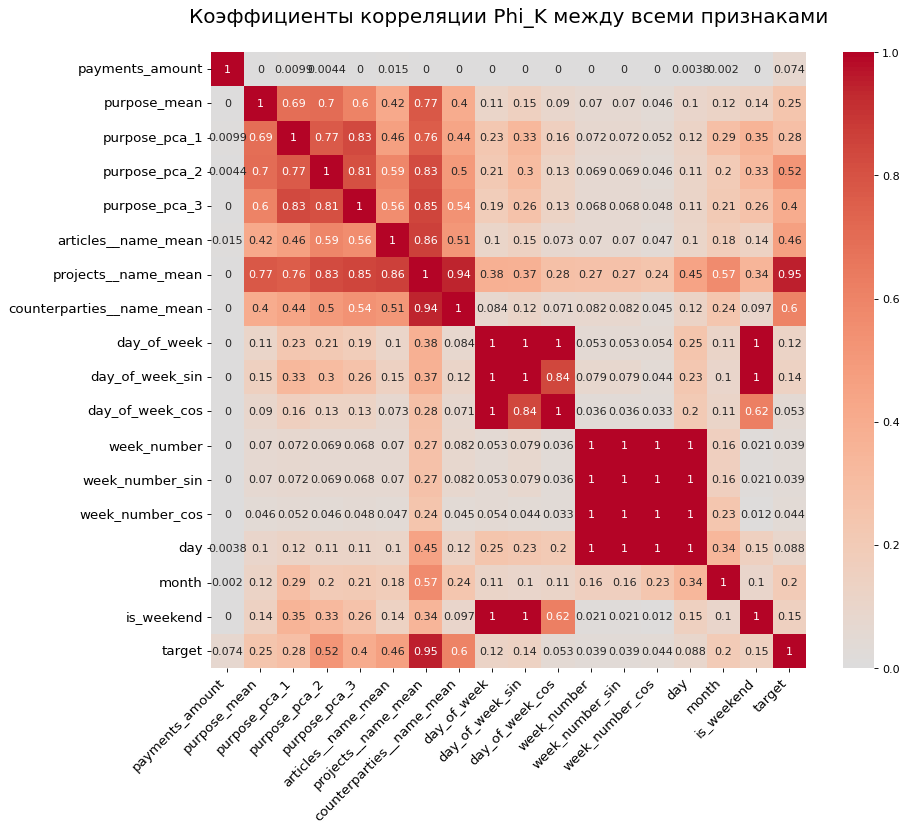

In [13]:
# считаем корреляцию
phik_matrix = data_corr.phik_matrix(interval_cols=['payments_amount', 'purpose_mean', 'purpose_pca_1',
                                                       'purpose_pca_2', 'purpose_pca_3','articles__name_mean',
                                                       'projects__name_mean	','counterparties__name_mean','day_of_week_sin','day_of_week_cos',
                                                       'week_number_sin','week_number_cos'])

# сразу будем смотреть heatmap
plt.figure(figsize=(12,10), dpi= 80)
sns.heatmap(phik_matrix.values, xticklabels=phik_matrix.columns, yticklabels=phik_matrix.index, cmap='coolwarm', center=0, annot=True)

plt.title('Коэффициенты корреляции Phi_K между всеми признаками\n', fontsize=18)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12, rotation='horizontal')
plt.show()

In [14]:
# корреляция с id бесполезна, потому что модель идеально выучит соответствие между id и таргетом и потом при появлении новых id будет сбоить
# для инфо проверим корреляцию id  с таргетом 

id_columns = ['user_id','account_id', 'contractor_id', 'article_id',
       'project_id', 'counterpartie_id', 'donor_id', 'donor_cat_id',
       'articles__parent_id', 'projects__parent_id',
       'counterparties__parent_id', 'robots__id']
target = 'target'

phi_k_with_target = {}

for col in id_columns:
    phi_value = data_prepared[[col, target]].phik_matrix(interval_cols=[]).iloc[0, 1]
    phi_k_with_target[col] = phi_value

phi_k_series = pd.Series(phi_k_with_target)
print(phi_k_series)

/opt/anaconda3/envs/datasphere_cli_env/lib/python3.10/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable account_id is large: 1914. Are you sure this is not an interval variable? Analysis for pairs of variables including account_id can be slow.
  warnings.warn(
/opt/anaconda3/envs/datasphere_cli_env/lib/python3.10/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable contractor_id is large: 97835. Are you sure this is not an interval variable? Analysis for pairs of variables including contractor_id can be slow.
  warnings.warn(
/opt/anaconda3/envs/datasphere_cli_env/lib/python3.10/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable article_id is large: 1807. Are you sure this is not an interval variable? Analysis for pairs of variables including article_id can be slow.
  warnings.warn(
/opt/anaconda3/envs/datasphere_cli_env/lib/python3.10/site-packages/phik/data_qualit

user_id                      0.839865
account_id                   0.928545
contractor_id                0.905522
article_id                   1.000000
project_id                   0.967271
counterpartie_id             0.317933
donor_id                     0.374228
donor_cat_id                 0.987501
articles__parent_id          0.987467
projects__parent_id          0.794202
counterparties__parent_id    0.920015
robots__id                   0.962265
dtype: float64


## Посмотрим корреляции по Mutual Information

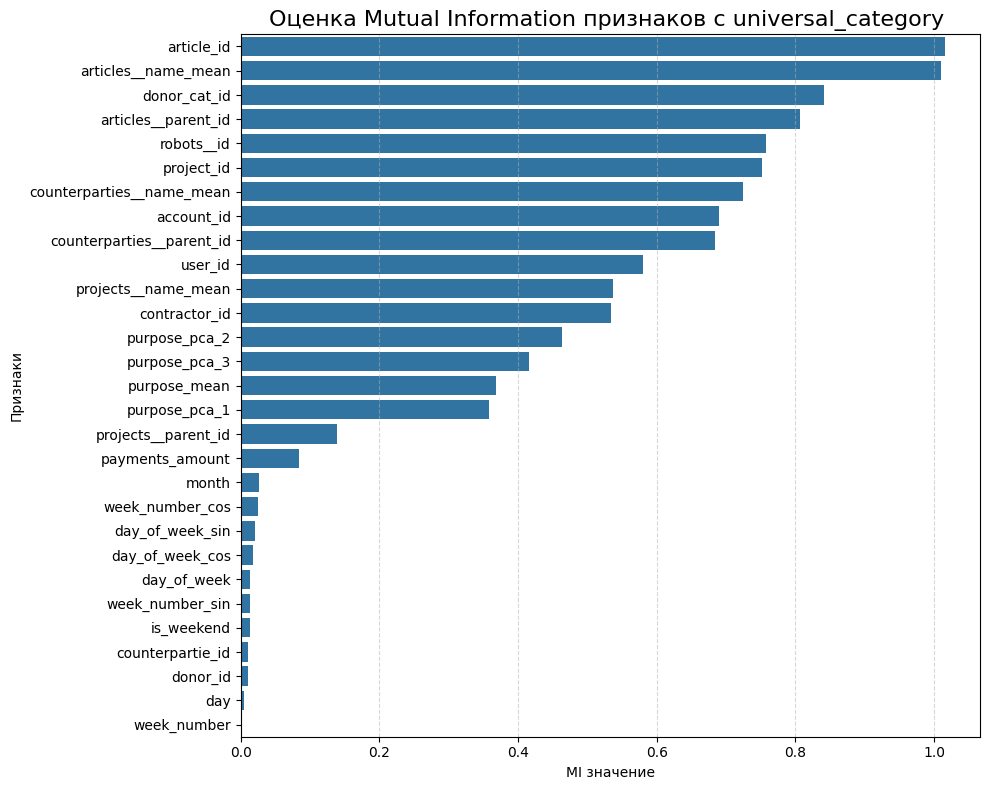

In [15]:
X = data_prepared.drop(['target'],axis=1)
y = data_prepared['target']

cat = ['user_id','account_id', 'contractor_id', 'article_id',
       'project_id', 'counterpartie_id', 'donor_id', 'donor_cat_id',
       'articles__parent_id', 'projects__parent_id',
       'counterparties__parent_id', 'robots__id','day_of_week', 'week_number', 'day', 'month', 'is_weekend']

discrete_mask = X.columns.isin(cat)
mi_scores = mutual_info_classif(X, y, discrete_features=discrete_mask, random_state=42)

mi_series_sorted = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=mi_series_sorted.values, y=mi_series_sorted.index)
plt.title('Оценка Mutual Information признаков с universal_category ', fontsize=16)
plt.xlabel('MI значение')
plt.ylabel('Признаки')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Вывод**: Корреляция по Phi_K показала наличие связи целевого признака универсальной категории с текстовыми представлениями назначения платежа, статьи, проекта и категории донора, а также более слабые связи с днем недели, месяцем и выходным днем. Данные с ID показали высокую корреляцию - на части из них происходило исходное распределение универсальных категорий, а по другим есть строгие связи между статьей, проектом и категорией донора - проблема в том, что в случае добавления новых категорий в ID модель начнет путаться и выдавать шумные данные, так как в самих ID нет смысловой нагрузки. Проверка связей по Mutual Information в целом подтвредило выводы выше.  
В связи с этим имеет смысла обучать модель на числовых представлениях текстовых признаков, а также добавить признаки на базе даты (день, месяц, выходной), признаки показавшие уровень корреляции менее 10% исключим.

**UPDATE!**
C учетом исправления расчета усредненных эмбеддингов перепроверим корреляцию на отобранных ранее признаках: 

/opt/anaconda3/envs/datasphere_cli_env/lib/python3.10/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable projects__name_mean is large: 1828. Are you sure this is not an interval variable? Analysis for pairs of variables including projects__name_mean can be slow.
  warnings.warn(


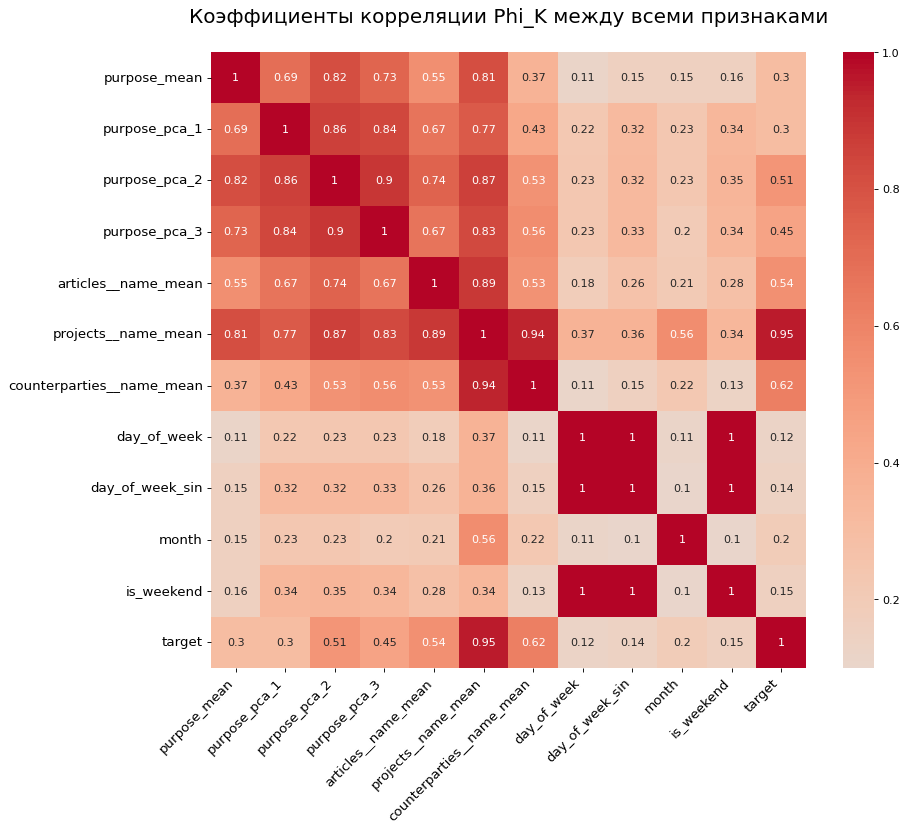

In [16]:
data_prepared = pd.read_parquet('data_prepared_server.parquet')

data_corr = data_prepared[['purpose_mean', 'purpose_pca_1', 'purpose_pca_2', 'purpose_pca_3',
       'articles__name_mean', 'projects__name_mean',
       'counterparties__name_mean', 'day_of_week', 'day_of_week_sin', 'month',
       'is_weekend', 'target']]

# считаем корреляцию
phik_matrix = data_corr.phik_matrix(interval_cols=['purpose_mean', 'purpose_pca_1',
                                                       'purpose_pca_2', 'purpose_pca_3','articles__name_mean',
                                                       'projects__name_mean	','counterparties__name_mean','day_of_week_sin'])

# сразу будем смотреть heatmap
plt.figure(figsize=(12,10), dpi= 80)
sns.heatmap(phik_matrix.values, xticklabels=phik_matrix.columns, yticklabels=phik_matrix.index, cmap='coolwarm', center=0, annot=True)

plt.title('Коэффициенты корреляции Phi_K между всеми признаками\n', fontsize=18)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12, rotation='horizontal')
plt.show()

Вывод: из-за уточнения расчета кодирования - корреляция на текстовых признаках подросла.

**UPDATE!** При обучении моделей и анализе важности признаков - и для RandomForest, и для Catboost производные признаки на базе даты не подтвердили свой вклад:

```python
# добавляем признаки, производные из даты с учетом анализа в EDA
data["day_of_week"] = data["date"].dt.weekday
data["day_of_week_sin"] = np.sin(2 * np.pi * data["day_of_week"] / 7).round(6)
data["month"] = data["date"].dt.month
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)


feature  importance 
4         articles__name_mean    0.269056  
6   counterparties__name_mean    0.184938  
2               purpose_pca_2    0.138113  
5         projects__name_mean    0.135164  
3               purpose_pca_3    0.108656  
1               purpose_pca_1    0.094191  
0                purpose_mean    0.054753  
9                       month    0.011656  
7                 day_of_week    0.001550  
8             day_of_week_sin    0.001384  
10                 is_weekend    0.000540  

 feature  importance  
4         articles__name_mean   23.511952  
6   counterparties__name_mean   15.459770  
3               purpose_pca_3   15.140428  
2               purpose_pca_2   14.293711  
1               purpose_pca_1   13.145628  
5         projects__name_mean    9.020180  
0                purpose_mean    4.861915  
9                       month    2.743115  
7                 day_of_week    1.081299  
8             day_of_week_sin    0.568553  
10                 is_weekend    0.173448  
```

В продакшн версии исключим эти признаки.